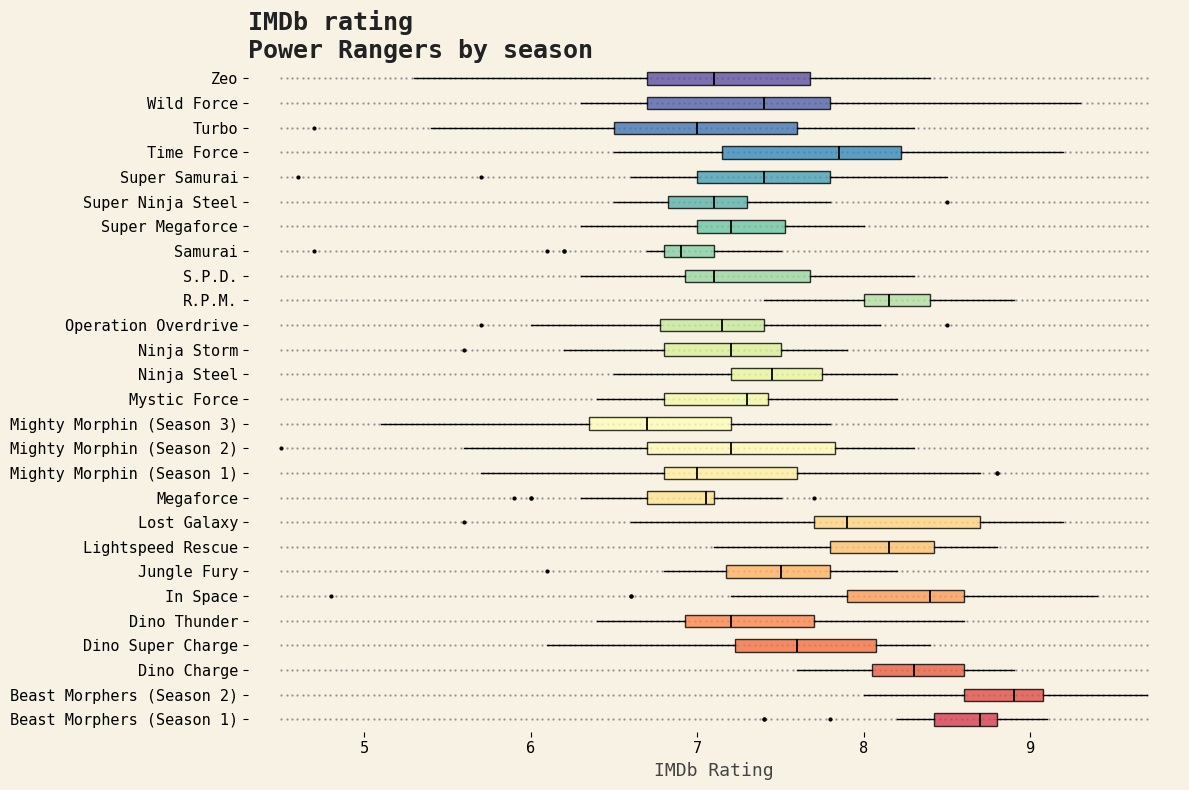

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# --- Font and style setup ---
rcParams['font.family'] = 'monospace'
rcParams['font.serif'] = ['consolas']
rcParams['axes.titlesize'] = 18
rcParams['axes.titleweight'] = 'bold'
rcParams['axes.labelsize'] = 13
rcParams['xtick.labelsize'] = 11
rcParams['ytick.labelsize'] = 11

# --- Load data ---
df = pd.read_csv("power_rangers_episodes.csv")
df = df.dropna(subset=["IMDB_rating"])

# Group IMDb ratings by season
grouped = df.groupby("season_title")["IMDB_rating"].apply(list)
# grouped = grouped.reindex(grouped.apply(np.median).sort_values().index)  # Sort by median rating
grouped = grouped.sort_index()  # sort by season_title alphabetically

# --- Create plot ---
fig, ax = plt.subplots(figsize=(12, 8))

# Boxplot
box = ax.boxplot(
    grouped,
    vert=False,
    patch_artist=True,
    tick_labels=grouped.index,
    medianprops=dict(color='black', linewidth=1.3),
    boxprops=dict(linewidth=1.0),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=0),
    flierprops=dict(marker='o', markerfacecolor='black', markersize=2, alpha=1)
)

# --- gradient ---
colors = plt.cm.Spectral(np.linspace(0.1, 1, len(grouped)))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)


# --- Horizontal dotted lines (spaced dots) ---
for y in range(1, len(grouped) + 1):
    x_points = np.linspace(df["IMDB_rating"].min(), df["IMDB_rating"].max(), 160)
    ax.scatter(x_points, [y]*len(x_points), color='gray', s=0.5, alpha=0.7)

# --- Style and layout ---
ax.set_title("IMDb rating\nPower Rangers by season", loc='left', color="#222222")
ax.set_xlabel("IMDb Rating", color="#444444")
ax.set_xlim(df["IMDB_rating"].min() - 0.2, df["IMDB_rating"].max() + 0.2)

# Hide gridlines & spines
ax.grid(False)
for spine in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine].set_visible(False)

# Background
ax.set_facecolor("#f8f2e4")
fig.patch.set_facecolor("#f8f2e4")

# Adjust spacing
plt.tight_layout()
plt.show()
